# XGBoost


## 1. Importing libraries

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
 
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from scipy.stats import randint, uniform
 

In [39]:
# Setting global parameters for consistency across all visualisations
 
# Which GSADF label column to use as the prediction target:
#   "gsadf_label_95"  →  95% confidence interval (stricter bubble detection)
#   "gsadf_label_90"  →  90% confidence interval (more sensitive)
TARGET_COL = "gsadf_label_95"
 
# Columns that are NOT model features and must be dropped before training.
# 'fear_greed_classification' is the raw string sentiment label — it is
# encoded into the numeric 'sentiment_ordinal' feature and then dropped.
NON_FEATURE_COLS = [
    "date",
    "symbol",
    "fear_greed_classification",
    "gsadf_label_95",
    "gsadf_label_90",
]
 
# Fixed string → integer label mapping (must match GSADF output exactly)
LABEL_STR_TO_INT = {
    "Not Bubble"      : 0,
    "Bubble Creation" : 1,
    "Bubble Collapse" : 2,
}
LABEL_MAP   = {v: k for k, v in LABEL_STR_TO_INT.items()}   # 0→"Not Bubble" etc.
CLASS_NAMES = ["Not Bubble", "Bubble Creation", "Bubble Collapse"]
 
# Fear & Greed text → ordinal integer (used as a numeric feature)
SENTIMENT_ORDINAL = {
    "Extreme Fear" : 0,
    "Fear"         : 1,
    "Neutral"      : 2,
    "Greed"        : 3,
    "Extreme Greed": 4,
}
 
# Plot colours for the three classes
COLORS = ["#4C72B0", "#DD8452", "#55A868"]
 
# Output directory — all plots and CSV statistics are saved here
OUTPUT_DIR = "xgboost_stats"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "monospace",
})
 

## 2. Loading Data

In [40]:
def load_and_preprocess(filepath: str) -> pd.DataFrame:
    """
    Load the CSV, clean it, and make it model-ready.
 
    Steps performed
    ---------------
    1. Parse dates; sort by date -> symbol (time-ordered within each coin)
    2. Encode 'fear_greed_classification' (text) as an ordinal integer feature
       called 'sentiment_ordinal':
           Extreme Fear=0, Fear=1, Neutral=2, Greed=3, Extreme Greed=4
    3. Impute missing numeric values (m2, cpi occasionally missing due to
       monthly reporting cadence) using forward-fill then backward-fill
       within each coin group, then global median as a final fallback
    4. Map string target column (gsadf_label_95 / gsadf_label_90) to
       integer labels: Not Bubble=0, Bubble Creation=1, Bubble Collapse=2
 
    Parameters
    ----------
    filepath : str   Path to the dataset CSV file.
 
    Returns
    -------
    pd.DataFrame with new integer column 'bubble_label' ready for modelling.
    """
    df = pd.read_csv(filepath, parse_dates=["date"])
 
    # ── Sort chronologically ───────────────────────────────────────────────────
    df.sort_values(["date", "symbol"], inplace=True)
    df.reset_index(drop=True, inplace=True)
 
    print(f"[load] Loaded       : {len(df):,} rows x {df.shape[1]} columns")
    print(f"[load] Symbols      : {sorted(df['symbol'].unique().tolist())}")
    print(f"[load] Date range   : {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"[load] Target col   : '{TARGET_COL}'")
    print(f"[load] Label counts :\n{df[TARGET_COL].value_counts().to_string()}\n")
 
    # ── Encode fear_greed_classification as ordinal numeric feature ───────────
    # The dataset already has a numeric 'fear_greed' score (0-100); this adds
    # a complementary ordinal encoding of the text category for the model.
    df["sentiment_ordinal"] = df["fear_greed_classification"].map(SENTIMENT_ORDINAL)
    unmapped = df["sentiment_ordinal"].isna().sum()
    if unmapped > 0:
        print(f"[preprocess] {unmapped} unmapped 'fear_greed_classification' values "
              f"-> set to 2 (Neutral)")
        df["sentiment_ordinal"].fillna(2, inplace=True)
 
    # ── Impute missing numeric values ─────────────────────────────────────────
    numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
    missing_before = df[numeric_cols].isna().sum()
    missing_before = missing_before[missing_before > 0]
    if not missing_before.empty:
        print(f"[preprocess] Missing values before imputation:\n{missing_before.to_string()}\n")
 
    df[numeric_cols] = (
        df.groupby("symbol")[numeric_cols]
        .transform(lambda g: g.ffill().bfill())
    )
    # Final fallback: global median for any remaining NaNs
    for col in numeric_cols:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)
 
    missing_after = df[numeric_cols].isna().sum().sum()
    print(f"[preprocess] Remaining NaNs after imputation: {missing_after}\n")
 
    # ── Replace infinity values ────────────────────────────────────────────────
    # Certain engineered features (ratios, z-scores, ROC, correlations) can
    # produce +inf / -inf when dividing by zero or a zero standard deviation.
    # Strategy: replace inf/-inf with NaN, then re-run the median fill.
    inf_counts = np.isinf(df[numeric_cols]).sum()
    inf_cols   = inf_counts[inf_counts > 0]
    if not inf_cols.empty:
        print(f"[preprocess] Infinity values found — replacing with column median:")
        print(inf_cols.to_string(), "\n")
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        for col in numeric_cols:
            if df[col].isna().any():
                df[col].fillna(df[col].median(), inplace=True)
    else:
        print("[preprocess] No infinity values found.\n")
 
    # ── Clip extreme outliers ──────────────────────────────────────────────────
    # As a final safety net, clip any values that exceed float64 safe range.
    # This catches edge cases that survive the inf→NaN→median pipeline.
    CLIP_LIMIT = 1e15
    df[numeric_cols] = df[numeric_cols].clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT)
    print(f"[preprocess] All numeric values clipped to [{-CLIP_LIMIT:.0e}, {CLIP_LIMIT:.0e}].\n")
 
    # ── Encode string labels -> integers ──────────────────────────────────────
    df["bubble_label"] = df[TARGET_COL].map(LABEL_STR_TO_INT)
    unmapped_labels    = df["bubble_label"].isna().sum()
    if unmapped_labels > 0:
        raise ValueError(
            f"{unmapped_labels} rows in '{TARGET_COL}' could not be mapped.\n"
            f"  Found    : {df[TARGET_COL].unique().tolist()}\n"
            f"  Expected : {list(LABEL_STR_TO_INT.keys())}"
        )
    df["bubble_label"] = df["bubble_label"].astype(int)
 
    return df
 
 
 


def split_features_target(df: pd.DataFrame):
    """
    Separate feature matrix X from integer target y.
 
    Columns dropped from X (non-feature identifiers / raw string labels):
      date, symbol, fear_greed_classification, gsadf_label_95,
      gsadf_label_90, bubble_label
 
    'sentiment_ordinal' (ordinal encoding of fear_greed_classification) IS
    kept as a numeric feature, alongside the existing numeric 'fear_greed'
    score and all other engineered columns.
 
    Parameters
    ----------
    df : DataFrame produced by load_and_preprocess()
 
    Returns
    -------
    X : pd.DataFrame  — fully numeric feature matrix
    y : pd.Series     — integer labels (0 = Not Bubble, 1 = Creation, 2 = Collapse)
    """
    drop_cols = NON_FEATURE_COLS + ["bubble_label"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["bubble_label"]
 
    # Confirm X is entirely numeric before passing to XGBoost
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        raise ValueError(
            f"Non-numeric columns remain in X: {non_numeric}\n"
            f"Add them to NON_FEATURE_COLS or encode them before training."
        )
 
    return X, y

## 3. Train/Test Split

In [41]:
def temporal_train_test_split(df: pd.DataFrame, test_ratio: float = 0.2):
    """
    Split by TIME, not randomly, to prevent data leakage.
 
    Because the dataset contains multiple coins sharing the same dates,
    we split on the unique sorted date axis:
      - All rows whose date falls in the LAST (test_ratio * 100)% of the
        date range become the test set.
      - Everything earlier is the training set.
 
    Parameters
    ----------
    df         : full preprocessed DataFrame
    test_ratio : fraction of time period to hold out (default 0.20)
 
    Returns
    -------
    X_train, X_test, y_train, y_test, df_train, df_test
    """
    unique_dates = sorted(df["date"].unique())
    cutoff_idx   = int(len(unique_dates) * (1 - test_ratio))
    cutoff_date  = unique_dates[cutoff_idx]
 
    df_train = df[df["date"] <  cutoff_date].copy()
    df_test  = df[df["date"] >= cutoff_date].copy()
 
    X_train, y_train = split_features_target(df_train)
    X_test,  y_test  = split_features_target(df_test)
 
    print(f"[split] Cut-off date : {pd.Timestamp(cutoff_date).date()}")
    print(f"[split] Train rows   : {len(X_train):,}  |  Test rows : {len(X_test):,}")
    print(f"[split] Train label distribution:\n"
          f"{y_train.value_counts().sort_index().rename(LABEL_MAP).to_string()}")
    print(f"[split] Test  label distribution:\n"
          f"{y_test.value_counts().sort_index().rename(LABEL_MAP).to_string()}\n")
 
    return X_train, X_test, y_train, y_test, df_train, df_test
 

## 4. SMOTE


In [42]:
def apply_smote(X_train: pd.DataFrame, y_train: pd.Series, random_state: int = 42):
    """
    Oversample minority classes (Bubble Creation & Collapse) on the training
    set only using SMOTE (Synthetic Minority Over-Sampling Technique).
 
    k_neighbors is set to min(5, minority_class_size - 1) so SMOTE does not
    crash when a class has very few samples.
 
    Returns
    -------
    X_res, y_res : numpy arrays with balanced class counts
    """
    min_class_count = y_train.value_counts().min()
    k = max(1, min(5, min_class_count - 1))
 
    print("[SMOTE] Class distribution BEFORE oversampling:")
    print(y_train.value_counts().sort_index().rename(LABEL_MAP).to_string(), "\n")
 
    smote        = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = smote.fit_resample(X_train, y_train)
 
    print("[SMOTE] Class distribution AFTER oversampling:")
    print(pd.Series(y_res).value_counts().sort_index().rename(LABEL_MAP).to_string(), "\n")
 
    return X_res, y_res
 

## 5. XGBoost

In [43]:

def build_baseline_xgboost(random_state: int = 42) -> xgb.XGBClassifier:
    """
    XGBoost classifier with sensible defaults for a 3-class problem.
 
    Key parameters
    --------------
    objective        : 'multi:softprob' — returns probabilities per class
    num_class        : 3
    n_estimators     : 300 boosting rounds (trees)
    max_depth        : 6 levels per tree
    learning_rate    : 0.05 — small steps for better generalisation
    subsample        : 0.8 — use 80% of rows per tree (reduces overfit)
    colsample_bytree : 0.8 — use 80% of features per tree (reduces overfit)
    reg_alpha/lambda : L1 / L2 regularisation penalties
    """
    return xgb.XGBClassifier(
        objective        = "multi:softprob",
        num_class        = 3,
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        gamma            = 0.1,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = "mlogloss",
        random_state     = random_state,
        n_jobs           = -1,
    )
 
 
def hyperparameter_tuning(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_iter: int     = 40,
    cv_folds: int   = 5,
    random_state: int = 42,
) -> xgb.XGBClassifier:
    """
    Randomised search over XGBoost's hyperparameter space.
 
    Uses StratifiedKFold to ensure each fold contains all 3 bubble classes.
    Scoring: weighted F1 (accounts for class imbalance).
 
    Parameters
    ----------
    n_iter   : number of random combinations to try (increase for better results,
               at the cost of longer runtime — 40 is a reasonable starting point)
    cv_folds : cross-validation folds (5 is standard)
 
    Returns
    -------
    best_estimator : XGBClassifier already fitted to full training data
    """
    param_distributions = {
        "n_estimators"     : randint(100, 600),
        "max_depth"        : randint(3, 10),
        "learning_rate"    : uniform(0.01, 0.2),
        "subsample"        : uniform(0.6, 0.4),
        "colsample_bytree" : uniform(0.5, 0.5),
        "min_child_weight" : randint(1, 15),
        "gamma"            : uniform(0, 0.5),
        "reg_alpha"        : uniform(0, 1.0),
        "reg_lambda"       : uniform(0.5, 2.0),
    }
 
    base_model = xgb.XGBClassifier(
        objective    = "multi:softprob",
        num_class    = 3,
        eval_metric  = "mlogloss",
        random_state = random_state,
        n_jobs       = -1,
    )
 
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
 
    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_distributions,
        n_iter              = n_iter,
        scoring             = "f1_weighted",
        cv                  = cv,
        verbose             = 1,
        random_state        = random_state,
        n_jobs              = -1,
        refit               = True,
    )
 
    print(f"[tuning] Running RandomizedSearchCV ({n_iter} iterations, {cv_folds}-fold CV)...")
    search.fit(X_train, y_train)
    print(f"\n[tuning] Best CV weighted-F1 : {search.best_score_:.4f}")
    print(f"[tuning] Best params:\n{pd.Series(search.best_params_).to_string()}\n")
 
    return search.best_estimator_
 
 
def train_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val:   np.ndarray,
    y_val:   np.ndarray,
    model:   xgb.XGBClassifier,
) -> xgb.XGBClassifier:
    """
    Fit XGBoost with early stopping on the validation set.
 
    Early stopping watches validation log-loss and halts training after
    30 consecutive rounds without improvement — prevents overfitting and
    saves time.
    """
    model.set_params(early_stopping_rounds=30)
    model.fit(
        X_train, y_train,
        eval_set = [(X_val, y_val)],
        verbose  = 50,
    )
    print(f"\n[train] Best boosting round : {model.best_iteration}\n")
    return model
 

## 6. Evaluation + Visualisations

In [44]:

def evaluate_model(
    model:      xgb.XGBClassifier,
    X_test:     pd.DataFrame,
    y_test:     pd.Series,
    model_name: str = "XGBoost",
) -> dict:
    """
    Compute and print a full statistical evaluation.
 
    Metrics
    -------
    Per-class  : Precision, Recall, F1
    Aggregate  : Macro F1, Weighted F1, Macro Precision, Macro Recall
    ROC-AUC    : One-vs-Rest weighted average (requires predict_proba)
 
    Returns
    -------
    dict with all metric values plus raw predictions and probabilities
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)   # shape (n_samples, 3)
 
    precision_pc = precision_score(y_test, y_pred, average=None,       zero_division=0)
    recall_pc    = recall_score(   y_test, y_pred, average=None,       zero_division=0)
    f1_pc        = f1_score(       y_test, y_pred, average=None,       zero_division=0)
    f1_macro     = f1_score(       y_test, y_pred, average="macro",    zero_division=0)
    f1_weighted  = f1_score(       y_test, y_pred, average="weighted", zero_division=0)
    prec_macro   = precision_score(y_test, y_pred, average="macro",    zero_division=0)
    rec_macro    = recall_score(   y_test, y_pred, average="macro",    zero_division=0)
    roc_auc      = roc_auc_score(  y_test, y_prob, multi_class="ovr",  average="weighted")
 
    print("=" * 65)
    print(f"  EVALUATION -- {model_name}")
    print("=" * 65)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
    print(f"  Macro     F1        : {f1_macro:.4f}")
    print(f"  Weighted  F1        : {f1_weighted:.4f}")
    print(f"  Macro     Precision : {prec_macro:.4f}")
    print(f"  Macro     Recall    : {rec_macro:.4f}")
    print(f"  ROC-AUC (weighted)  : {roc_auc:.4f}")
    print("=" * 65 + "\n")
 
    return {
        "model_name"         : model_name,
        "y_pred"             : y_pred,
        "y_prob"             : y_prob,
        "precision_per_class": precision_pc,
        "recall_per_class"   : recall_pc,
        "f1_per_class"       : f1_pc,
        "f1_macro"           : f1_macro,
        "f1_weighted"        : f1_weighted,
        "precision_macro"    : prec_macro,
        "recall_macro"       : rec_macro,
        "roc_auc"            : roc_auc,
    }
 
 
# =============================================================================
# SECTION 7 — VISUALISATIONS
# =============================================================================
 
def plot_confusion_matrix(y_test, y_pred, model_name: str = "XGBoost"):
    """
    Normalised confusion matrix.
    Rows = true class, Columns = predicted class.
    Diagonal cells = correct predictions; off-diagonal = errors.
    Values shown as proportions (0.00-1.00).
    """
    cm   = confusion_matrix(y_test, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion Matrix (Normalised) -- {model_name}", fontsize=13, pad=12)
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f"confusion_matrix_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()
    print(f"[plot] Saved: {fname}\n")
 
 
def plot_per_class_metrics(results: dict):
    """
    Grouped bar chart: Precision / Recall / F1 for each bubble class.
    Quickly shows which class the model struggles to predict.
    """
    metrics = {
        "Precision": results["precision_per_class"],
        "Recall"   : results["recall_per_class"],
        "F1-Score" : results["f1_per_class"],
    }
    x     = np.arange(len(CLASS_NAMES))
    width = 0.25
 
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (name, vals) in enumerate(metrics.items()):
        bars = ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], alpha=0.85)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics -- {results['model_name']}", fontsize=13)
    ax.legend(loc="upper right")
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f"per_class_metrics_{results['model_name'].replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()
    print(f"[plot] Saved: {fname}\n")
 
 
def plot_feature_importance(model: xgb.XGBClassifier, top_n: int = 20):
    """
    Horizontal bar chart of the top_n features ranked by 'gain'.
    Gain = average reduction in prediction error brought by each feature
    across all trees.  Higher gain -> more important feature.
    """
    importance = model.get_booster().get_score(importance_type="gain")
    imp_df = (
        pd.DataFrame.from_dict(importance, orient="index", columns=["Gain"])
        .rename_axis("Feature").reset_index()
        .sort_values("Gain", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
    ax.barh(imp_df["Feature"][::-1], imp_df["Gain"][::-1], color="#4C72B0", alpha=0.85)
    ax.set_xlabel("Gain (Feature Importance)")
    ax.set_title(f"Top {top_n} Features by Gain", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=130)
    plt.show()
    print("[plot] Saved: feature_importance.png\n")
 
 
def plot_learning_curve(model: xgb.XGBClassifier):
    """
    Training vs validation log-loss over boosting rounds.
    If validation loss rises while training loss keeps falling -> overfitting.
    The red dashed line marks where early stopping chose to stop.
    """
    evals = model.evals_result()
    if not evals:
        print("[plot] No eval results -- skipping learning curve.")
        return
    val_key  = list(evals.keys())[-1]
    val_loss = evals[val_key]["mlogloss"]
 
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(val_loss, label="Validation Loss", color="#DD8452")
    ax.axvline(model.best_iteration, color="red", linestyle=":",
               label=f"Best round ({model.best_iteration})")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("Multiclass Log-Loss")
    ax.set_title("Learning Curve -- XGBoost", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "learning_curve.png"), dpi=130)
    plt.show()
    print("[plot] Saved: learning_curve.png\n")
 
 
def plot_class_distribution(y_before, y_after):
    """
    Side-by-side bar charts showing class counts before and after SMOTE.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, y, title in zip(
        axes,
        [y_before, y_after],
        ["Before SMOTE (Train)", "After SMOTE (Train)"],
    ):
        counts = pd.Series(y).value_counts().sort_index().rename(LABEL_MAP)
        ax.bar(range(len(counts)), counts.values, color=COLORS, alpha=0.85, edgecolor="white")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=10, ha="right")
        ax.set_title(title, fontsize=11)
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.suptitle("Class Distribution Before vs After SMOTE", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution_smote.png"), dpi=130)
    plt.show()
    print("[plot] Saved: class_distribution_smote.png\n")
 
 
 
# Export statistics for all models to a single CSV for easy comparison
def export_metrics_to_csv(results_list: list, filepath: str = None):
    """
    Write per-class and aggregate metrics for all models to a single CSV.
    Makes it easy to compare Baseline XGBoost, Tuned XGBoost, and LSTM.
    """
    if filepath is None:
        filepath = os.path.join(OUTPUT_DIR, "model_metrics_summary.csv")
    rows = []
    for r in results_list:
        for i, cls in enumerate(CLASS_NAMES):
            rows.append({
                "Model"    : r["model_name"],
                "Class"    : cls,
                "Precision": round(r["precision_per_class"][i], 4),
                "Recall"   : round(r["recall_per_class"][i],    4),
                "F1-Score" : round(r["f1_per_class"][i],        4),
            })
        for label, val in [
            ("-- MACRO AVG --",           r["f1_macro"]),
            ("-- WEIGHTED AVG (F1) --",   r["f1_weighted"]),
            ("-- ROC-AUC (weighted) --",  r["roc_auc"]),
        ]:
            rows.append({"Model": r["model_name"], "Class": label,
                         "Precision": "--", "Recall": "--", "F1-Score": round(val, 4)})
 
    df_out = pd.DataFrame(rows)
    df_out.to_csv(filepath, index=False)
    print(f"[export] Metrics saved -> '{filepath}'\n")
    return df_out

## 7. Cross-Asset Analysis

In [45]:
 
def evaluate_per_coin(model: xgb.XGBClassifier, df_test: pd.DataFrame) -> pd.DataFrame:
    """
    Run evaluation separately for each cryptocurrency in the test set.
    Answers Sub-question (2): do bubble warning signals generalise across coins?
 
    Parameters
    ----------
    model   : fitted XGBClassifier
    df_test : test-split DataFrame (still contains 'symbol' and 'bubble_label')
    """
    rows = []
    for coin in sorted(df_test["symbol"].unique()):
        subset = df_test[df_test["symbol"] == coin].copy()
        X_coin, y_coin = split_features_target(subset)
        y_pred = model.predict(X_coin)
 
        f1s = f1_score(y_coin, y_pred, average=None, zero_division=0)
        # Pad to 3 values if a class is absent from this coin's test subset
        f1s = np.pad(f1s, (0, max(0, 3 - len(f1s))))
 
        rows.append({
            "Coin"             : coin,
            "F1 Not Bubble"    : round(f1s[0], 4),
            "F1 Bubble Creat." : round(f1s[1], 4),
            "F1 Bubble Coll."  : round(f1s[2], 4),
            "F1 Weighted"      : round(f1_score(y_coin, y_pred,
                                                 average="weighted", zero_division=0), 4),
        })
 
    df_coins = pd.DataFrame(rows)
    print("\n[per-coin] F1 Scores by Cryptocurrency:")
    print(df_coins.to_string(index=False))
    df_coins.to_csv(os.path.join(OUTPUT_DIR, "per_coin_f1_scores.csv"), index=False)
    print("[export] Saved -> 'xgboost_stats/per_coin_f1_scores.csv'\n")
    return df_coins
 
 
def plot_per_coin_heatmap(df_coins: pd.DataFrame):
    """
    Heatmap of F1 scores across coins and bubble states.
    Dark cells = high F1 (model predicts that class well for that coin).
    Light cells = poor F1 (model struggles).
    """
    heat_df = df_coins.set_index("Coin")[
        ["F1 Not Bubble", "F1 Bubble Creat.", "F1 Bubble Coll."]
    ]
    fig, ax = plt.subplots(figsize=(7, len(df_coins) * 0.6 + 1.5))
    sns.heatmap(
        heat_df, annot=True, fmt=".2f", cmap="YlGnBu",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
    )
    ax.set_title("F1 Score Heatmap by Coin & Bubble State", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "per_coin_f1_heatmap.png"), dpi=130)
    plt.show()
    print("[plot] Saved: per_coin_f1_heatmap.png\n")
 

## 8. Final Pipeline


  DSE4211 GROUP 18 -- XGBoost Bubble Prediction Pipeline

[load] Loaded       : 13,365 rows x 135 columns
[load] Symbols      : ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL']
[load] Date range   : 2018-05-01 -> 2025-01-01
[load] Target col   : 'gsadf_label_95'
[load] Label counts :
gsadf_label_95
Not Bubble         11498
Bubble Creation     1437
Bubble Collapse      430

[preprocess] 6 unmapped 'fear_greed_classification' values -> set to 2 (Neutral)
[preprocess] Remaining NaNs after imputation: 0

[preprocess] Infinity values found — replacing with column median:
trend_price_corr_30     68
trend_volume_corr_30    35 

[preprocess] All numeric values clipped to [-1e+15, 1e+15].

[split] Cut-off date : 2023-09-02
[split] Train rows   : 10,437  |  Test rows : 2,928
[split] Train label distribution:
bubble_label
Not Bubble         9005
Bubble Creation    1019
Bubble Collapse     413
[split] Test  label distribution:
bubble_label
Not Bubble         2493
Bubble Creation     418
Bubble Collaps

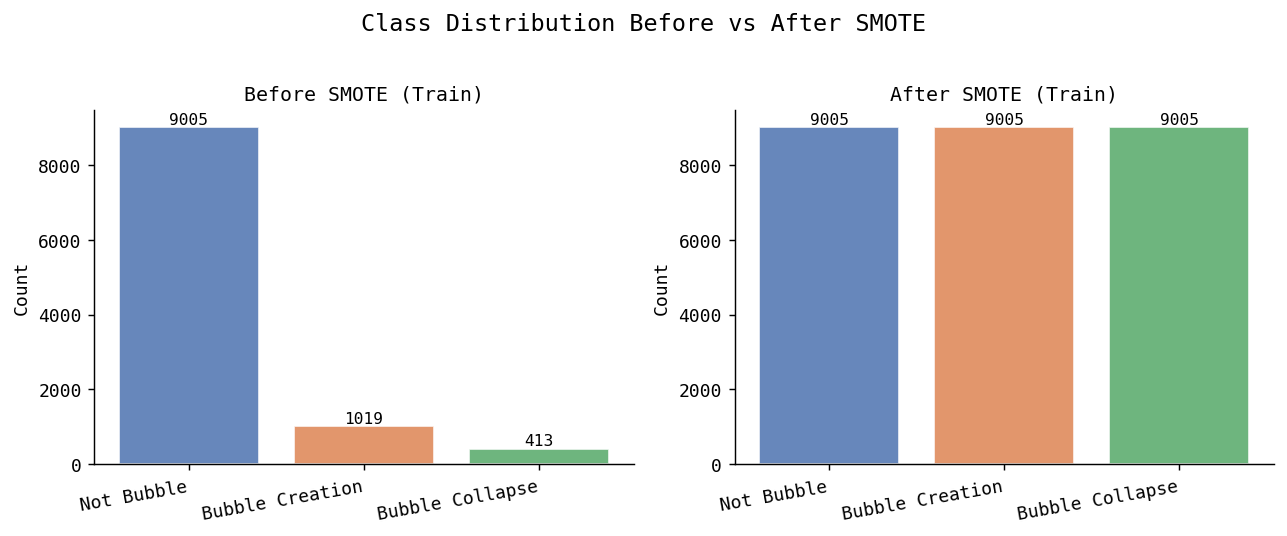

[plot] Saved: class_distribution_smote.png


-- BASELINE MODEL ------------------------------------------
[0]	validation_0-mlogloss:1.04421
[50]	validation_0-mlogloss:0.50942
[68]	validation_0-mlogloss:0.53953

[train] Best boosting round : 39

  EVALUATION -- XGBoost Baseline
                 precision    recall  f1-score   support

     Not Bubble     0.8532    0.9767    0.9108      2493
Bubble Creation     1.0000    0.0311    0.0603       418
Bubble Collapse     0.0492    0.1765    0.0769        17

       accuracy                         0.8371      2928
      macro avg     0.6341    0.3948    0.3493      2928
   weighted avg     0.8695    0.8371    0.7845      2928

  Macro     F1        : 0.3493
  Weighted  F1        : 0.7845
  Macro     Precision : 0.6341
  Macro     Recall    : 0.3948
  ROC-AUC (weighted)  : 0.7405


-- HYPERPARAMETER TUNING -----------------------------------
[tuning] Running RandomizedSearchCV (40 iterations, 5-fold CV)...
Fitting 5 folds for each of 40 candi

In [ ]:
def main(filepath: str = "data/df_features_with_labels.csv"):
    """
    End-to-end pipeline.
 
    1.  Load & preprocess dataset
    2.  Chronological train/test split
    3.  SMOTE oversampling on training set
    4.  Train & evaluate baseline XGBoost
    5.  Hyperparameter tuning -> train & evaluate tuned XGBoost
    6.  Generate all plots
    7.  Export metrics CSV
    8.  Per-coin cross-asset F1 analysis
    """
    print("\n" + "=" * 65)
    print("  DSE4211 GROUP 18 -- XGBoost Bubble Prediction Pipeline")
    print("=" * 65 + "\n")
 
    # ── 1. Load ───────────────────────────────────────────────────────────────
    df = load_and_preprocess(filepath)
 
    # ── 2. Split ──────────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test, df_train, df_test = \
        temporal_train_test_split(df, test_ratio=0.2)
 
    # ── 3. SMOTE ──────────────────────────────────────────────────────────────
    y_before_smote           = y_train.copy()
    X_train_res, y_train_res = apply_smote(X_train, y_train)
    plot_class_distribution(y_before_smote, y_train_res)
 
    # ── 4. Baseline XGBoost ───────────────────────────────────────────────────
    print("\n-- BASELINE MODEL ------------------------------------------")
    baseline = build_baseline_xgboost()
    baseline = train_model(X_train_res, y_train_res, X_test, y_test, baseline)
    res_base = evaluate_model(baseline, X_test, y_test, "XGBoost Baseline")
 
    # ── 5. Tuned XGBoost ──────────────────────────────────────────────────────
    print("\n-- HYPERPARAMETER TUNING -----------------------------------")
    tuned     = hyperparameter_tuning(X_train_res, y_train_res, n_iter=40, cv_folds=5)
    tuned     = train_model(X_train_res, y_train_res, X_test, y_test, tuned)
    res_tuned = evaluate_model(tuned, X_test, y_test, "XGBoost Tuned")
 
    # ── 6. Plots ──────────────────────────────────────────────────────────────
    print("\n-- GENERATING PLOTS ----------------------------------------")
    plot_confusion_matrix(y_test, res_base["y_pred"],  "XGBoost Baseline")
    plot_confusion_matrix(y_test, res_tuned["y_pred"], "XGBoost Tuned")
    plot_per_class_metrics(res_base)
    plot_per_class_metrics(res_tuned)
    plot_feature_importance(tuned, top_n=20)
    plot_learning_curve(tuned)
 
    # ── 7. Export ─────────────────────────────────────────────────────────────
    print("\n-- EXPORTING STATISTICS ------------------------------------")
    summary = export_metrics_to_csv([res_base, res_tuned])
    print(summary.to_string(index=False))
 
    # ── 8. Per-coin ───────────────────────────────────────────────────────────
    print("\n-- PER-COIN CROSS-ASSET ANALYSIS ---------------------------")
    df_coins = evaluate_per_coin(tuned, df_test)
    plot_per_coin_heatmap(df_coins)
 
    print("\n[done] Pipeline complete. All outputs saved.")
    return tuned, res_tuned


# Entry point for script execution
if __name__ == "__main__":
    # Path to the dataset CSV produced by the feature engineering pipeline
    FILEPATH = "data/df_features_with_labels.csv"
    tuned_model, final_results = main(FILEPATH)
